# Import Statements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Exploratory Data Analysis (EDA)
## Load the Dataset
### Basic Exploration

In [2]:
df=pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
df.shape

(500, 6)

In [5]:
df.describe().T #Summary Statistics

,count,mean,std,min,25%,50%,75%,max
Drug Dosage (mg),500.0,-0.037761,0.979891,-3.019512,-0.642003,-0.019340,0.641151,2.949094
Systolic Blood Pressure (mmHg),500.0,0.214957,1.247567,-3.773897,-0.565168,0.201532,0.951375,4.111751
Heart Rate (BPM),500.0,0.062871,0.971978,-2.940389,-0.648157,0.027732,0.710774,3.193108
Liver Toxicity Index (U/L),500.0,0.054398,0.986001,-3.401277,-0.586085,-0.065661,0.633914,3.373269
Blood Glucose Level (mg/dL),500.0,-0.171863,0.983765,-3.110431,-0.797715,-0.108106,0.513555,2.518023
Drug Response,500.0,0.520000,0.500100,0.000000,0.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum() # Missing Values

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [7]:
df.info() #Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


# Histogram

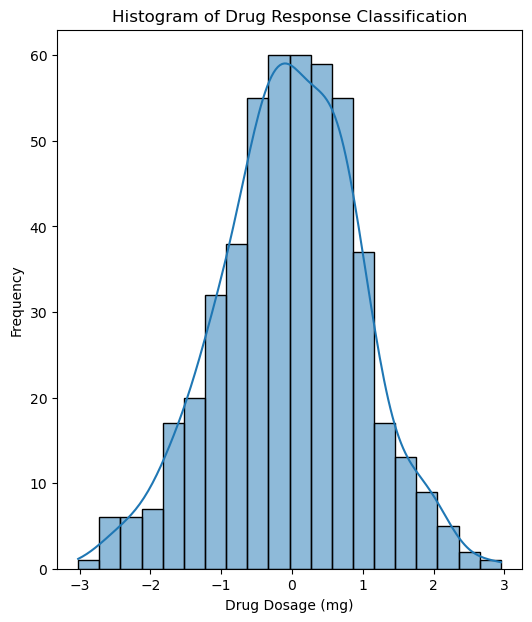

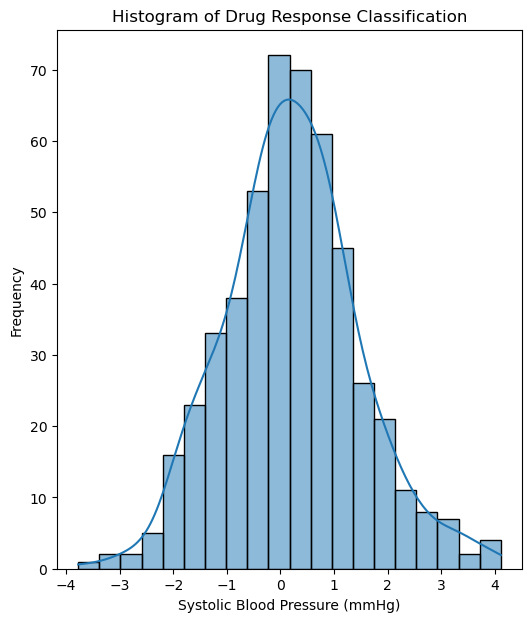

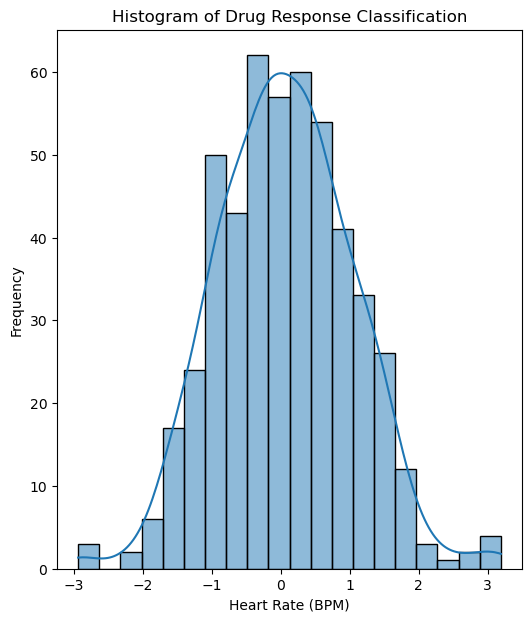

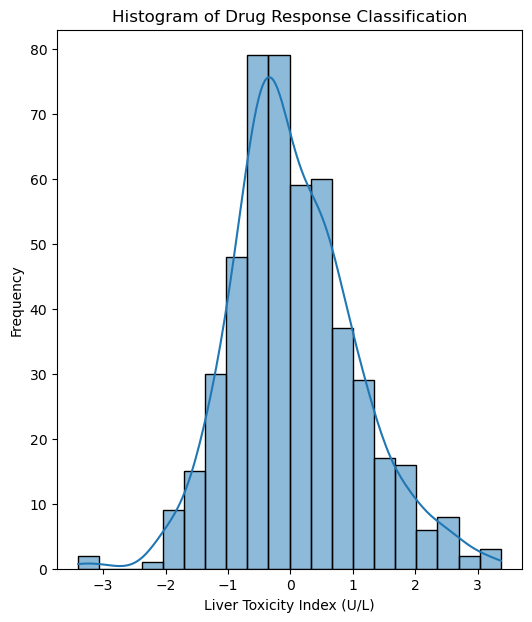

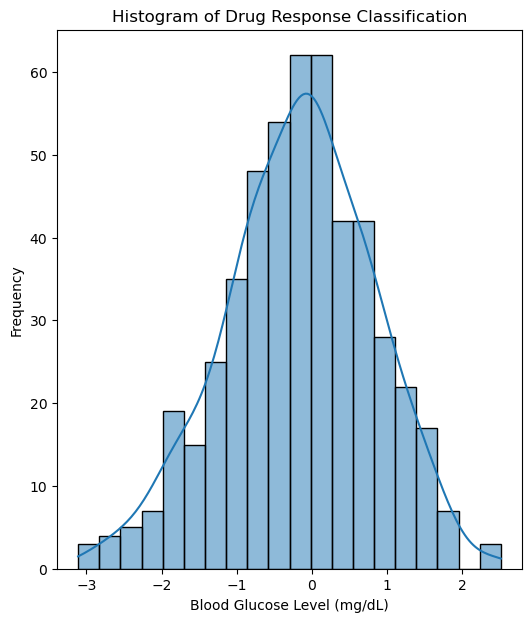

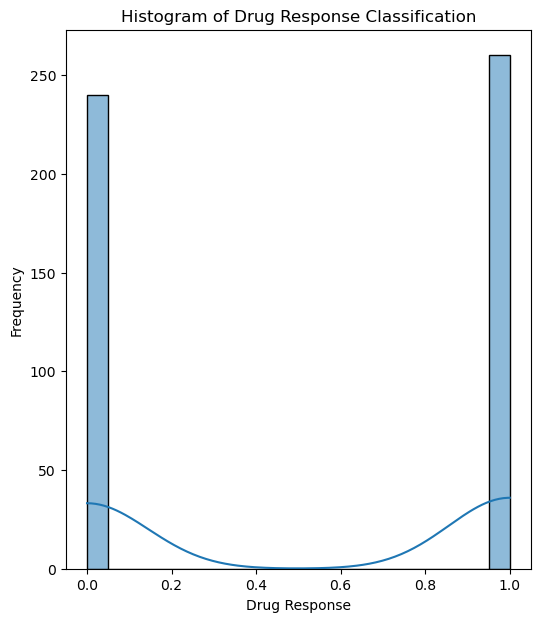

In [10]:
for col in df:
    plt.figure(figsize=(6,7))
    sns.histplot(data=df,x=col,bins=20,kde=True)
    plt.title("Histogram of Drug Response Classification")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# BoxPlot (use for finding outliers)

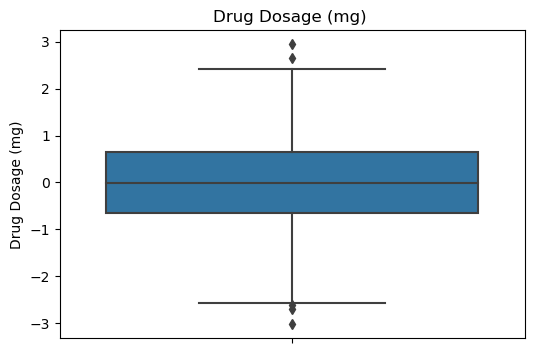

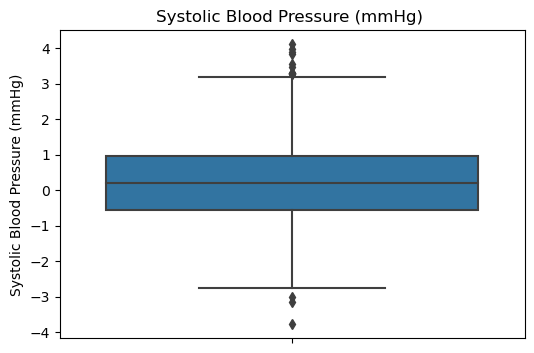

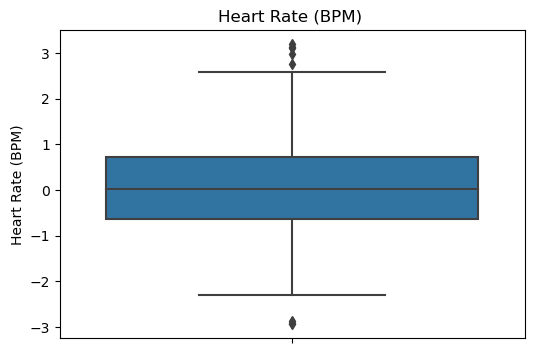

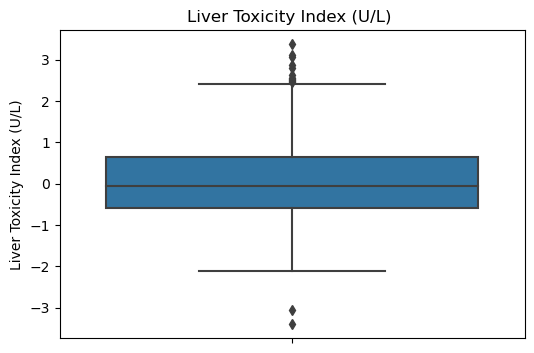

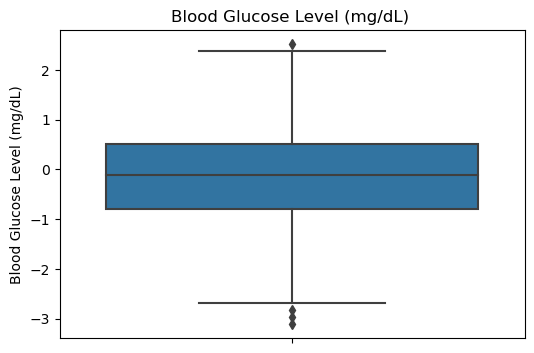

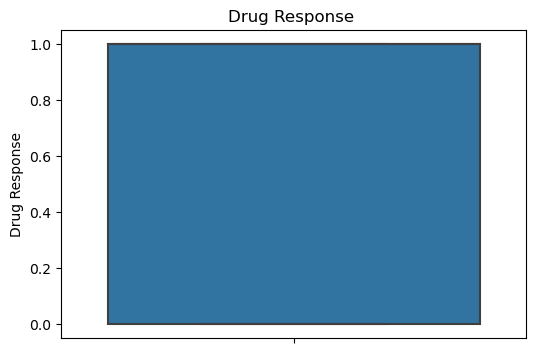

In [15]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, y=col)
    plt.title(f"{col} ")
    plt.show()

# Removing Outliers USing IQR

In [16]:
for col in df:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=df[col].clip(lower,upper)
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


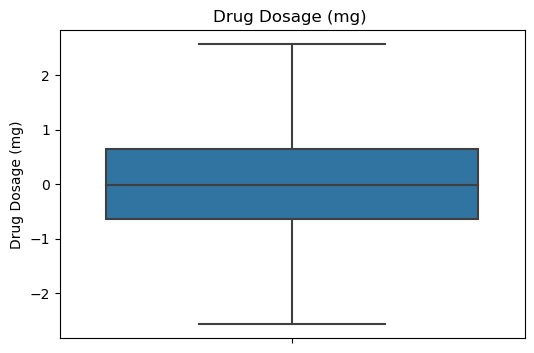

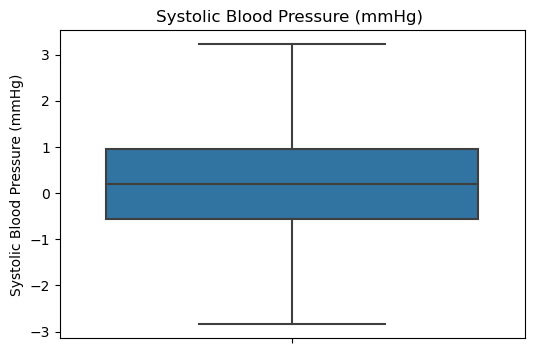

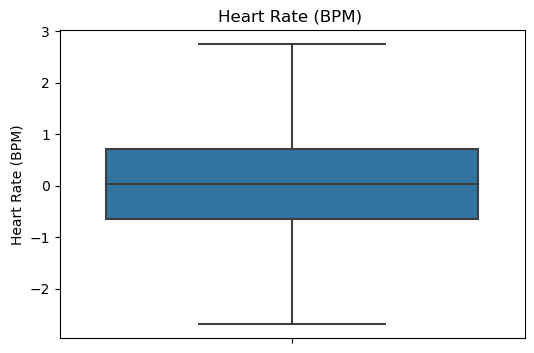

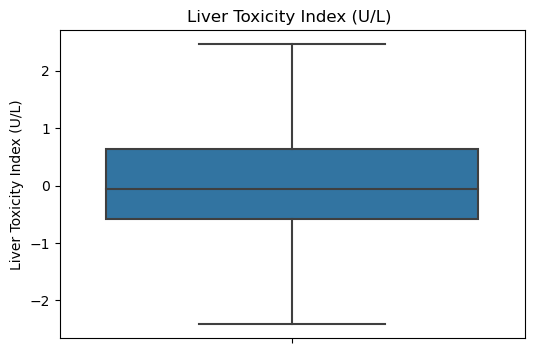

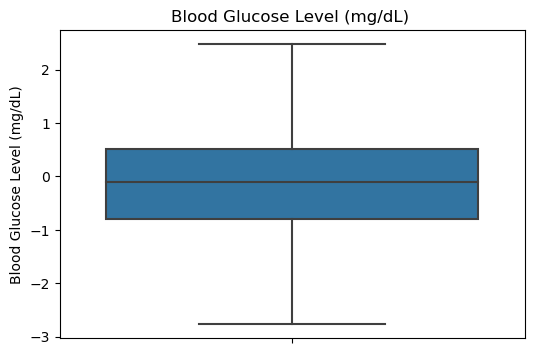

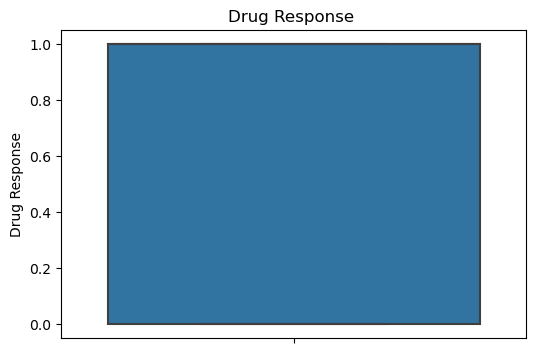

In [17]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, y=col)
    plt.title(f"{col} ")
    plt.show()

# Density Plots

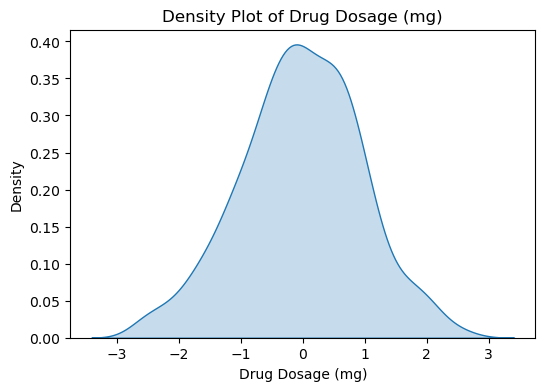

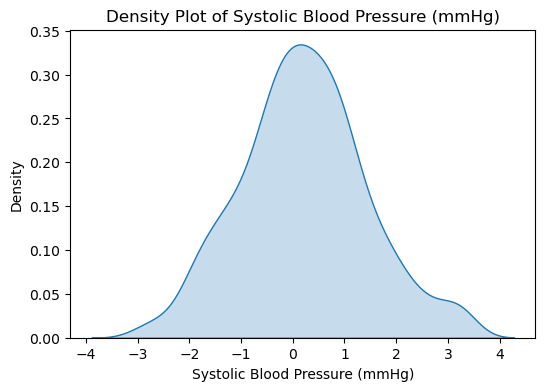

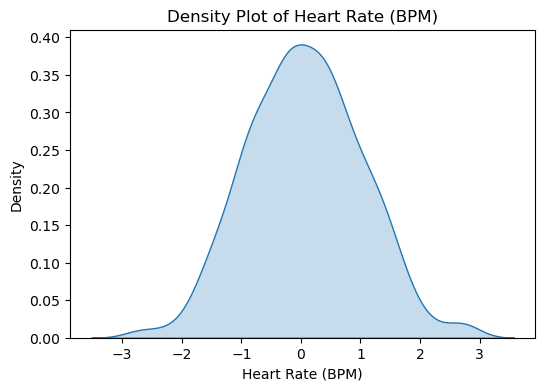

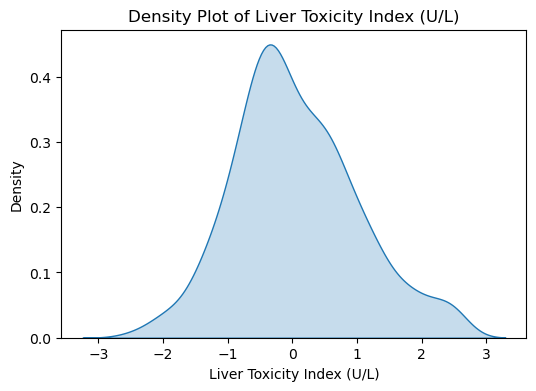

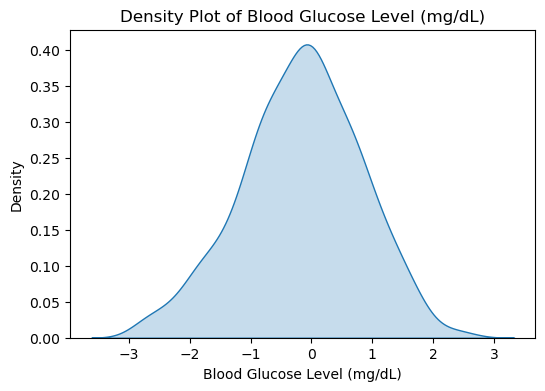

In [21]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Density Plot of {col}")
    plt.show()

# Feature Correlation

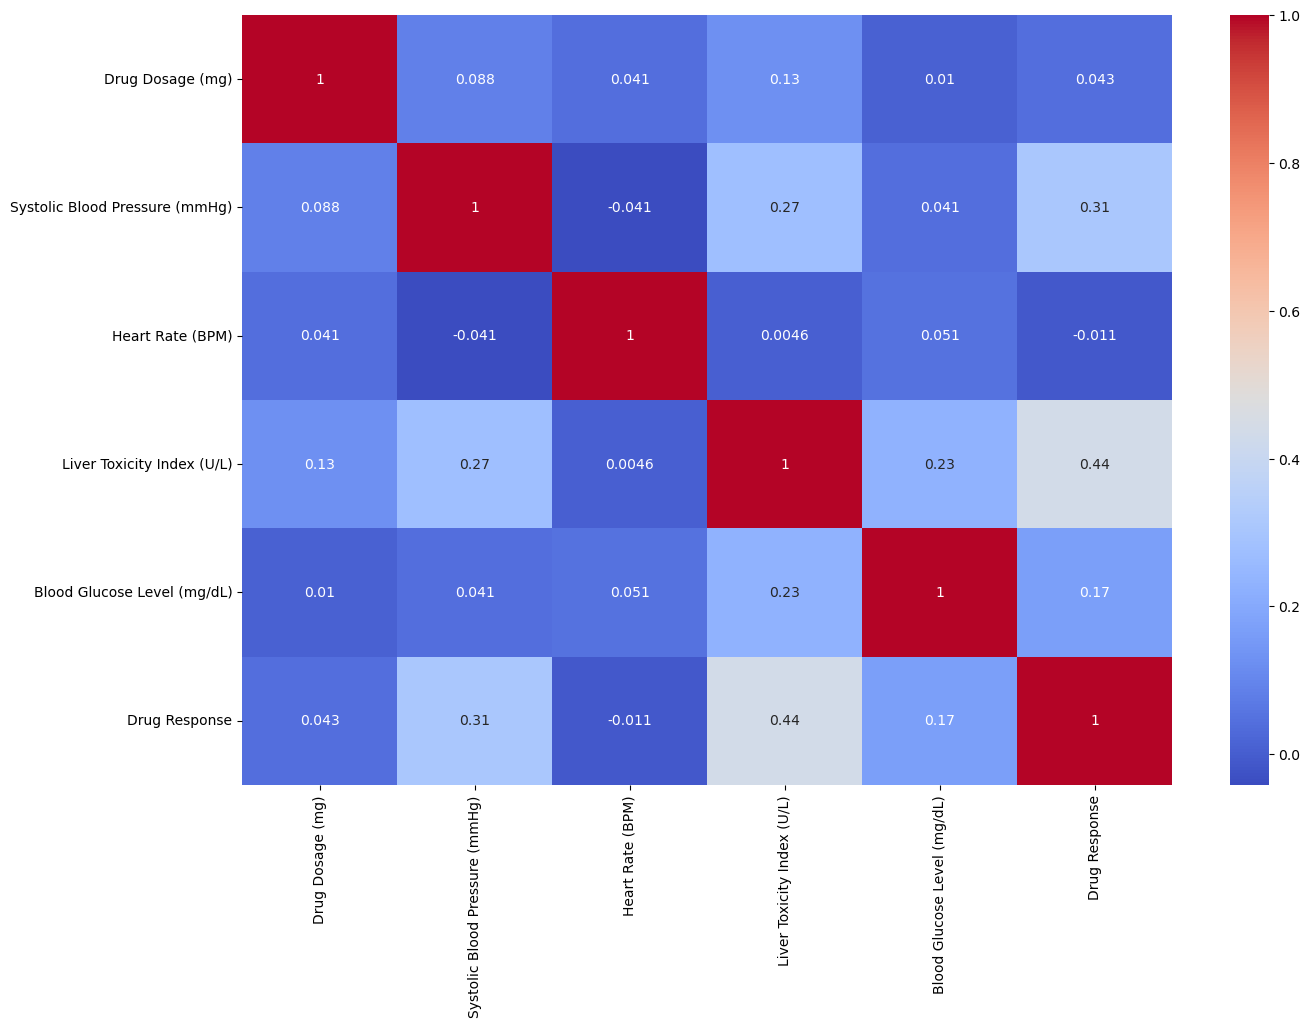

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

# Task2: Data Preprocessing
#### Since every predictor is already numeric, no encoding is required.
## Split the data:

In [36]:
from sklearn.model_selection import train_test_split
X=df.drop("Drug Response",axis=1)
Y=df["Drug Response"]
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)

# Task 3: Data Visualization
## 1.Scatter Plot
##### Since the target is binary (0/1), scatter plots are acceptable, but points will overlap because the y-axis has only two values.

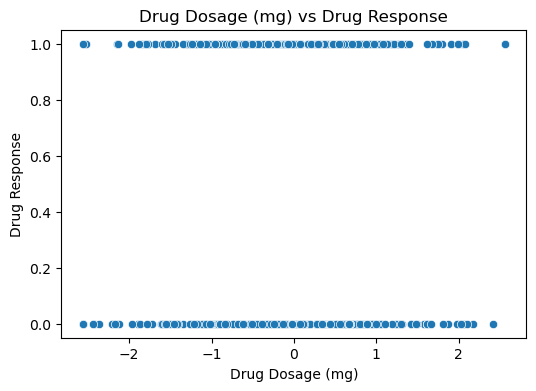

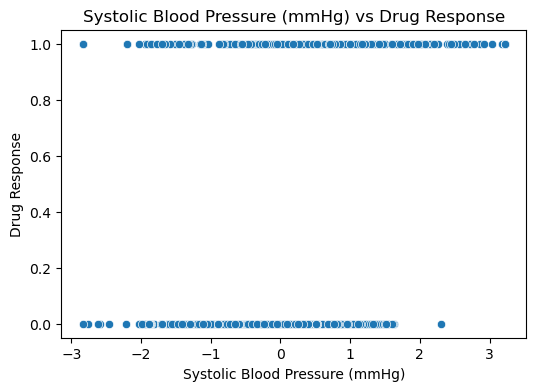

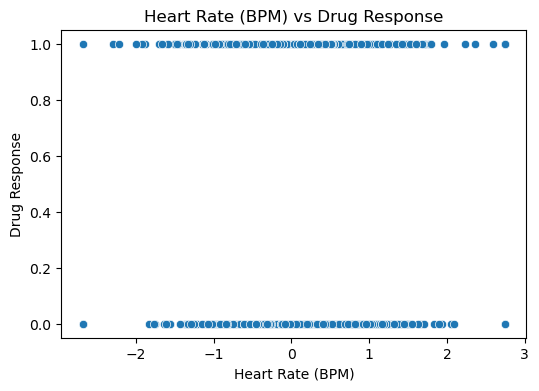

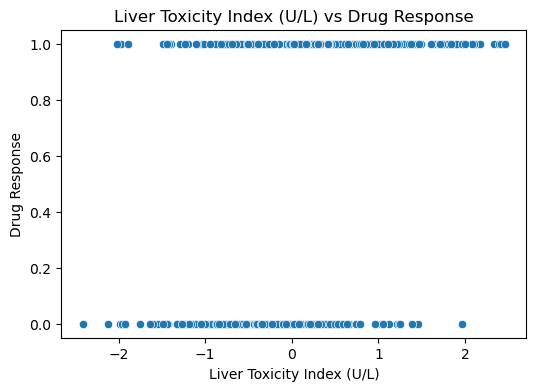

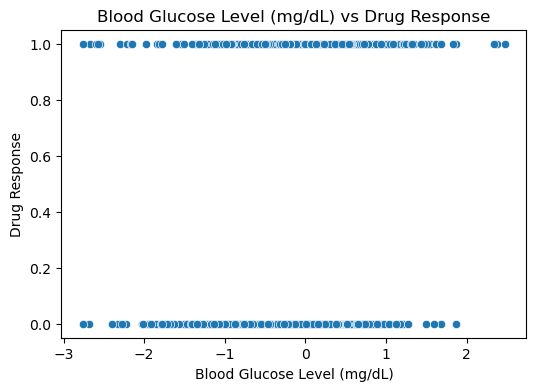

In [29]:
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df,x=col,y="Drug Response")
    plt.title(f"{col} vs Drug Response")
    plt.show()

## 2. Pair Plot

C:\Users\maddi\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


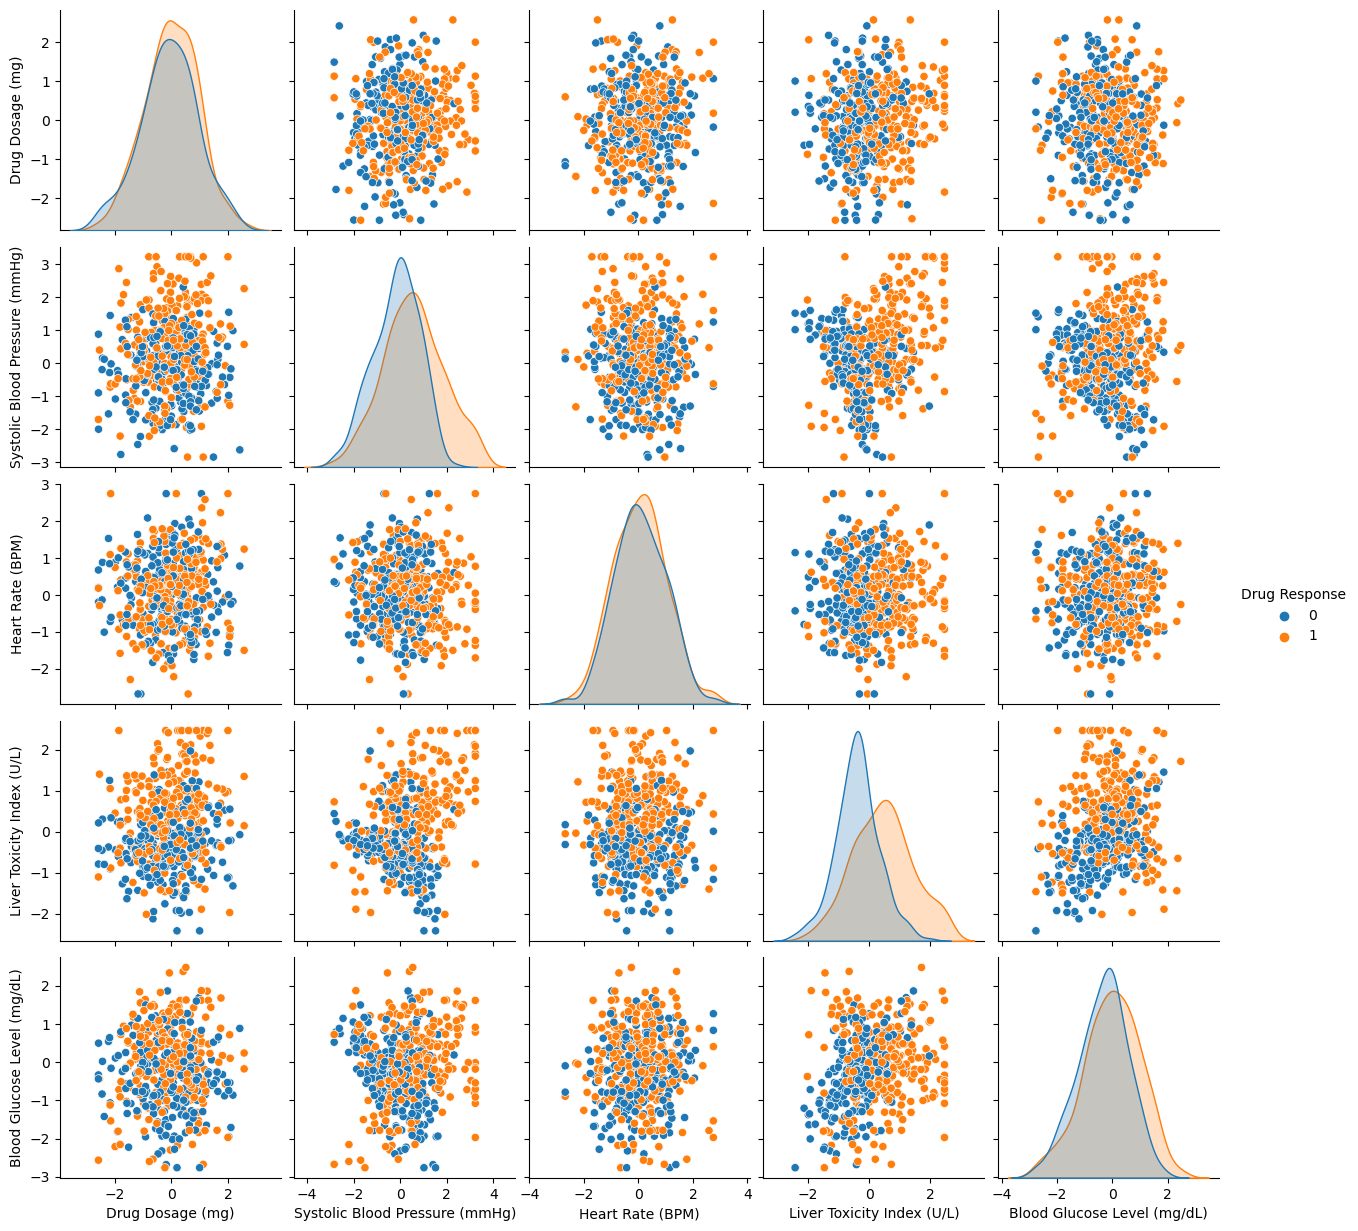

In [30]:
sns.pairplot(df,hue="Drug Response")
plt.show()

## 3.Class Distribution

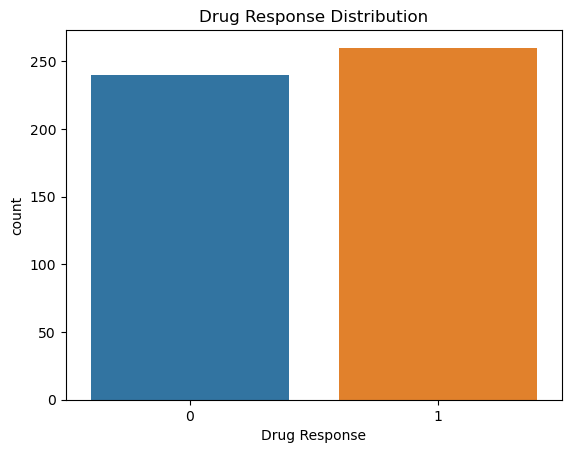

In [31]:
sns.countplot(x="Drug Response", data=df)
plt.title("Drug Response Distribution")
plt.show()

# Task 4: SVM Implementation

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
from sklearn.svm import SVC
svm = SVC(kernel="linear", random_state=42)
svm.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### Prediction of train and test data

In [39]:
#train data
y_train_pred = svm.predict(X_train)

#test data
y_test_pred = svm.predict(X_test)


### Evaluation

In [40]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

#Evaluation of train data
print("Accuracy of train data:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

# Evaluation on test data
print("Accuracy of test data:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

Accuracy of train data: 0.7428571428571429
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       168
           1       0.78      0.70      0.74       182

    accuracy                           0.74       350
   macro avg       0.75      0.74      0.74       350
weighted avg       0.75      0.74      0.74       350

[[133  35]
 [ 55 127]]
Accuracy of test data: 0.72
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        72
           1       0.76      0.68      0.72        78

    accuracy                           0.72       150
   macro avg       0.72      0.72      0.72       150
weighted avg       0.72      0.72      0.72       150

[[55 17]
 [25 53]]


# Task 5: Visualization of SVM Results
#### Confusion Matrix

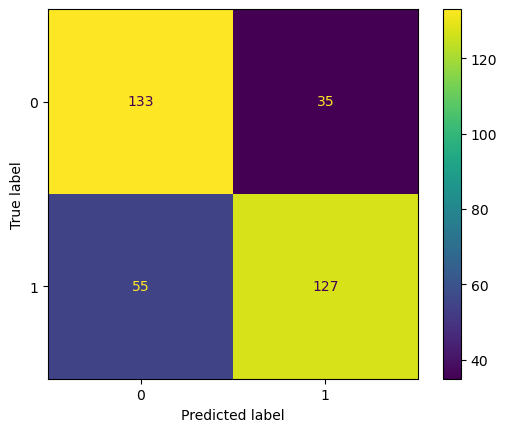

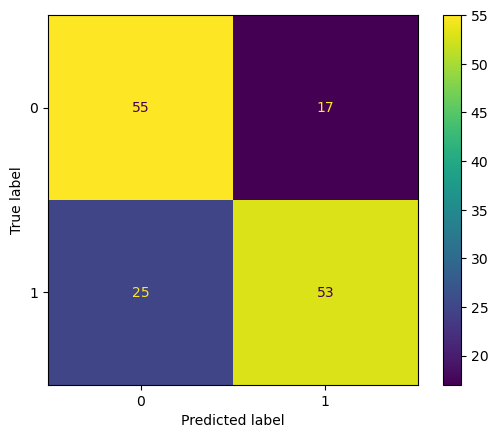

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
# train data
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()
#test data
print("="*70)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.show()

# ROC Curve

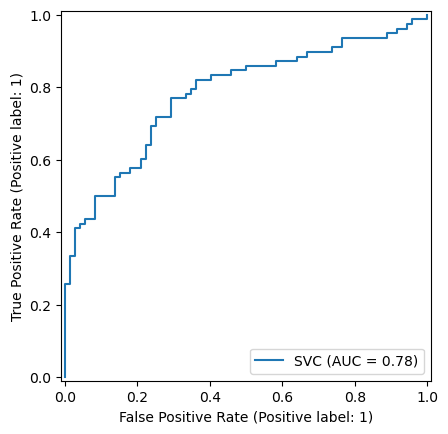

In [44]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(svm, X_test, y_test)
plt.show()

# Task 6: Parameter Tuning

In [45]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "poly", "rbf"],
    "gamma": ["scale", "auto"]
}
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
0.7628571428571429


# Task7: Kernel Comparison

In [46]:
from sklearn.metrics import accuracy_score
kernels = ["linear", "poly", "rbf"]
for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{kernel} Kernel Accuracy:",
          accuracy_score(y_test, pred))

linear Kernel Accuracy: 0.72
poly Kernel Accuracy: 0.68
rbf Kernel Accuracy: 0.7666666666666667


### 1.Analyze SVM Strengths and Weaknesses for the Dataset Based on EDA and Visualization Results

**Strengths of SVM**

- **Effective for high-dimensional data:** SVM performs well when the dataset contains many features, as it identifies the optimal hyperplane that maximizes the margin between classes.
- **Handles non-linear relationships:** If the EDA or scatter plots indicate that classes are not linearly separable, kernel functions (such as RBF or Polynomial) enable SVM to model complex decision boundaries.
- **Robust to overfitting:** By maximizing the margin between classes, SVM generally provides good generalization, especially when the dataset has a clear separation.
- **Works well with moderate-sized datasets:** For datasets with a reasonable number of samples, SVM often achieves high classification accuracy.
- **Less affected by outliers after preprocessing:** If EDA includes outlier detection and feature scaling, SVM becomes more reliable and produces better classification results.

**Weaknesses of SVM**

- **Sensitive to feature scaling:** Since SVM is distance-based, features must be standardized or normalized before model training.
- **Computationally expensive:** Training time increases significantly with very large datasets, making SVM less efficient than some other classifiers.
- **Kernel selection is challenging:** Choosing the appropriate kernel (Linear, Polynomial, RBF, or Sigmoid) and tuning hyperparameters such as C and gamma require experimentation.
- **Less interpretable:** Unlike Decision Trees or Logistic Regression, SVM does not provide easily interpretable decision rules.
- **Performance may decrease with noisy or overlapping classes:** If EDA reveals substantial class overlap or noise, SVM may struggle to identify an optimal separating hyperplane.

### 2.Practical Implications of SVM in Real-World Classification Tasks

Support Vector Machines are widely used in real-world applications because of their strong predictive performance, particularly for binary classification problems.

- **Medical Diagnosis:** SVM is used to classify diseases (e.g., cancer detection, diabetes prediction) by distinguishing between healthy and affected patients based on medical measurements.
- **Email Spam Detection:** SVM effectively classifies emails as spam or legitimate by analyzing text features.
- **Face and Image Recognition:** SVM is widely applied in computer vision to recognize faces, handwritten digits, and other objects from image data.
- **Fraud Detection:** Financial institutions use SVM to detect fraudulent transactions by learning patterns that distinguish legitimate and suspicious activities.
- **Text Classification:** SVM is commonly used for sentiment analysis, document categorization, and news classification due to its effectiveness with high-dimensional text features.
- **Bioinformatics:** It helps classify genes, proteins, and disease-related biological data where the number of features is typically very large.

**Practical Considerations:**

- SVM performs best when the dataset is properly preprocessed, including handling missing values, removing outliers, and scaling features.
- For very large datasets, training can become computationally expensive, so algorithms such as Random Forest or XGBoost may be preferred.
- Hyperparameter tuning using techniques like Grid Search or Cross-Validation is essential for achieving optimal performance.
- When combined with appropriate feature engineering and preprocessing, SVM provides reliable and accurate classification results across many real-world applications.